In [1]:
import os
os.environ["KAGGLE_API_TOKEN"] = "TOKEN"

!pip install -q kaggle
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images
!unzip -q cifake-real-and-ai-generated-synthetic-images.zip
!ls

Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100% 105M/105M [00:01<00:00, 88.0MB/s] 

cifake-real-and-ai-generated-synthetic-images.zip  sample_data	test  train


In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG = (96, 96)

train_ds = tf.keras.utils.image_dataset_from_directory(
    "train", image_size=IMG, batch_size=64, label_mode="binary")
test_ds = tf.keras.utils.image_dataset_from_directory(
    "test", image_size=IMG, batch_size=64, label_mode="binary")
print(train_ds.class_names)

base = MobileNetV2(input_shape=IMG + (3,), include_top=False, weights="imagenet")
base.trainable = False   # keep pretrained knowledge

model = models.Sequential([
    layers.Lambda(preprocess_input, input_shape=IMG + (3,)),
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(train_ds, validation_data=test_ds, epochs=3)

Found 100000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.
['FAKE', 'REAL']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 51s 26ms/step - accuracy: 0.8353 - loss: 0.3664 - val_accuracy: 0.8771 - val_loss: 0.2934
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.8565 - loss: 0.3287 - val_accuracy: 0.8810 - val_loss: 0.2826
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.8583 - loss: 0.3271 - val_accuracy: 0.8831 - val_loss: 0.2806


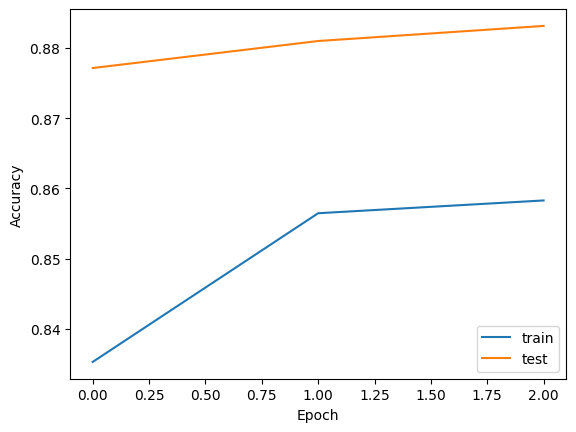

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8831 - loss: 0.2806
Test accuracy: 0.8831499814987183
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step


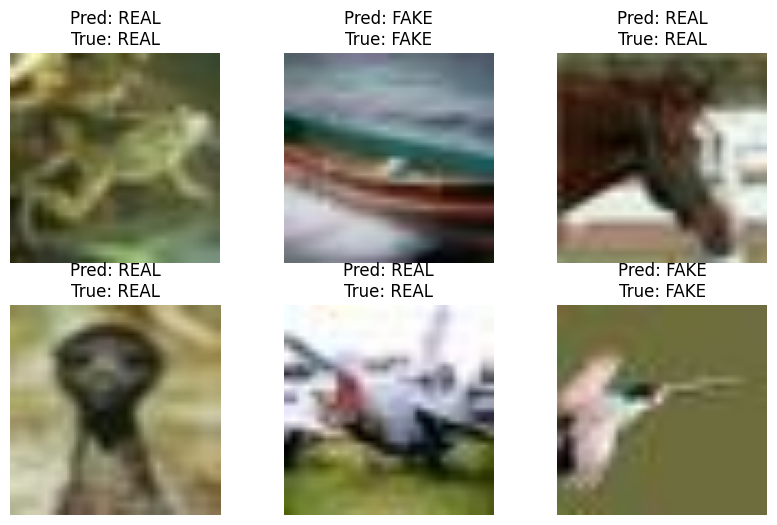

In [4]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="test")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.show()

loss, acc = model.evaluate(test_ds)
print("Test accuracy:", acc)

images, labels = next(iter(test_ds))
preds = model.predict(images)
names = ["FAKE", "REAL"]
plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(f"Pred: {names[int(preds[i][0] > 0.5)]}\nTrue: {names[int(labels[i][0])]}")
    plt.axis("off")
plt.show()